In [25]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import statsmodels
from scipy.stats import pearsonr, f_oneway, ttest_ind

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet('cleaned_eta.parquet', engine='pyarrow')

In [3]:
df.sample(5)

,order_id,store_id,zone,store_name,order_timestamp,total_items,fresh_item_count,picking_capacity,rider_capacity,traffic_level,weather_condition,actual_delivery_minutes,promised_delivery_mintes,distance_km,hour,is_peak_hour,day_name,is_weekend
185014,ord_185687,str_000009,HSR Extension,QuickMart Jayanagar,2026-04-23 16:01:00,1,0,12,12,High,Clear,15.0,15.0,1.35,16,False,Thursday,False
203307,ord_204050,str_000018,BTM Layout,QuickMart CV Raman Nagar,2026-05-04 17:56:00,4,0,16,12,High,Rain,13.0,13.0,0.69,17,False,Monday,False
285137,ord_286193,str_000002,Indiranagar,QuickMart HSR Layout,2026-06-23 09:27:00,2,0,10,12,High,Clear,13.0,15.0,1.06,9,False,Tuesday,False
1592,ord_001600,str_000012,Bellandur,QuickMart Yelahanka,2026-01-01 21:50:00,4,1,13,12,Normal,Clear,11.0,17.0,1.34,21,True,Thursday,False
50819,ord_050994,str_000025,Koramangala,QuickMart Ulsoor,2026-01-31 16:29:00,10,5,11,11,High,Clear,11.0,15.0,0.47,16,False,Saturday,True


In [4]:
df.shape

(298907, 18)

In [5]:
df.describe()

,order_timestamp,total_items,fresh_item_count,picking_capacity,rider_capacity,actual_delivery_minutes,promised_delivery_mintes,distance_km,hour
count,298907,298907.000000,298907.000000,298907.000000,298907.000000,298907.000000,298907.000000,298907.000000,298907.000000
mean,2026-04-01 15:48:00.491792,3.757988,0.726952,12.930139,14.878929,14.925746,16.904054,1.336106,15.137120
min,2026-01-01 00:03:00,1.000000,0.000000,7.000000,8.000000,5.000000,8.000000,0.250000,0.000000
25%,2026-02-14 19:51:00,2.000000,0.000000,10.000000,12.000000,12.000000,14.000000,0.820000,11.000000
50%,2026-04-01 09:41:00,3.000000,0.000000,13.000000,13.000000,14.000000,16.000000,1.200000,16.000000
75%,2026-05-17 09:25:00,5.000000,1.000000,16.000000,18.000000,17.000000,19.000000,1.720000,20.000000
max,2026-06-30 23:59:00,25.000000,14.000000,22.000000,26.000000,35.000000,35.000000,3.200000,23.000000
std,NaN,2.560708,1.172774,3.393883,4.192514,4.256027,4.390272,0.676525,5.202017


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 298907 entries, 0 to 298906
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  298907 non-null  str           
 1   store_id                  298907 non-null  str           
 2   zone                      298907 non-null  str           
 3   store_name                298907 non-null  str           
 4   order_timestamp           298907 non-null  datetime64[us]
 5   total_items               298907 non-null  int64         
 6   fresh_item_count          298907 non-null  int64         
 7   picking_capacity          298907 non-null  int64         
 8   rider_capacity            298907 non-null  int64         
 9   traffic_level             298907 non-null  str           
 10  weather_condition         298907 non-null  str           
 11  actual_delivery_minutes   298907 non-null  float64       
 12  promised_deli

In [8]:
df.columns

Index(['order_id', 'store_id', 'zone', 'store_name', 'order_timestamp',
       'total_items', 'fresh_item_count', 'picking_capacity', 'rider_capacity',
       'traffic_level', 'weather_condition', 'actual_delivery_minutes',
       'promised_delivery_mintes', 'distance_km', 'hour', 'is_peak_hour',
       'day_name', 'is_weekend'],
      dtype='str')

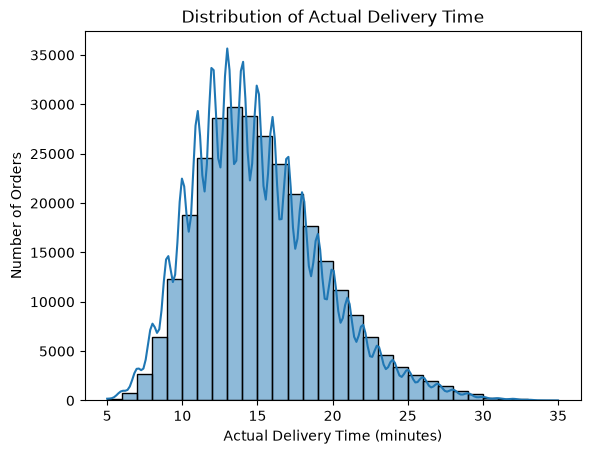

In [11]:
sns.histplot(df.actual_delivery_minutes, bins=30, kde=True)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Actual Delivery Time")
plt.show()

In [17]:
r, p_value = pearsonr(df.distance_km, df.actual_delivery_minutes)

print("corelation: ",r)
print("p_value: ", p_value)

corelation:  0.6667547252304318
p_value:  0.0


In [18]:
variables = [
    "total_items",
    "fresh_item_count",
    "picking_capacity",
    "rider_capacity",
]
for col in variables:
    r, p = pearsonr(df[col], df["actual_delivery_minutes"])
    print(f"{col}: r={r:.3f}, p={p:.4f}")

total_items: r=0.116, p=0.0000
fresh_item_count: r=0.102, p=0.0000
picking_capacity: r=-0.215, p=0.0000
rider_capacity: r=-0.201, p=0.0000


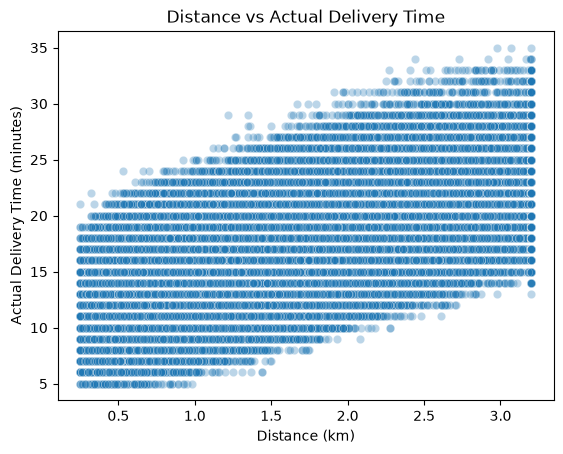

In [19]:
sns.scatterplot(data=df, x="distance_km", y="actual_delivery_minutes", alpha=0.3)

plt.xlabel("Distance (km)")
plt.ylabel("Actual Delivery Time (minutes)")
plt.title("Distance vs Actual Delivery Time")
plt.show()

In [20]:
df.groupby("is_peak_hour")["actual_delivery_minutes"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
is_peak_hour,,,,
False,192427,13.833329,13.0,3.844527
True,106480,16.899925,16.0,4.252512


In [21]:

peak = df.loc[df["is_peak_hour"] == True, "actual_delivery_minutes"]

non_peak = df.loc[df["is_peak_hour"] == False, "actual_delivery_minutes"]

t_stat, p_value = ttest_ind(peak, non_peak, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 195.26367919874318
p-value: 0.0


In [23]:
df.groupby("is_weekend")["actual_delivery_minutes"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
is_weekend,,,,
False,206762,14.788805,14.0,4.202100
True,92145,15.233024,15.0,4.359007


In [24]:
weekend = df.loc[df["is_weekend"] == True, "actual_delivery_minutes"]

non_weekend = df.loc[df["is_weekend"] == False, "actual_delivery_minutes"]

t_stat, p_value = ttest_ind(peak, non_peak, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 195.26367919874318
p-value: 0.0


In [26]:


normal = df.loc[df["traffic_level"] == "Normal", "actual_delivery_minutes"]

high = df.loc[df["traffic_level"] == "High", "actual_delivery_minutes"]

very_high = df.loc[df["traffic_level"] == "Very High", "actual_delivery_minutes"]

f_stat, p_value = f_oneway(normal, high, very_high)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 28823.94962779323
p-value: 0.0


In [27]:
df["items_per_picking_capacity"] = df["total_items"] / df["picking_capacity"]

df["items_per_rider_capacity"] = df["total_items"] / df["rider_capacity"]

df["fresh_item_ratio"] = df["fresh_item_count"] / df["total_items"]

In [28]:
new_features = [
    "items_per_picking_capacity",
    "items_per_rider_capacity",
    "fresh_item_ratio",
]

for col in new_features:
    r, p = pearsonr(df[col], df["actual_delivery_minutes"])

    print(f"{col}: r={r:.3f}, p={p:.4f}")

items_per_picking_capacity: r=0.188, p=0.0000
items_per_rider_capacity: r=0.179, p=0.0000
fresh_item_ratio: r=0.065, p=0.0000


In [29]:
df.head()

,order_id,store_id,zone,store_name,order_timestamp,total_items,fresh_item_count,picking_capacity,rider_capacity,traffic_level,...,actual_delivery_minutes,promised_delivery_mintes,distance_km,hour,is_peak_hour,day_name,is_weekend,items_per_picking_capacity,items_per_rider_capacity,fresh_item_ratio
0,ord_000001,str_000032,HSR Extension,QuickMart Whitefield Main Road,2026-01-01 00:03:00,2,0,10,12,Normal,...,11.0,14.0,1.73,0,False,Thursday,False,0.200000,0.166667,0.000000
1,ord_000002,str_000029,BTM Layout,QuickMart HSR Extension,2026-01-01 00:07:00,4,0,13,12,Normal,...,11.0,12.0,1.11,0,False,Thursday,False,0.307692,0.333333,0.000000
2,ord_000003,str_000001,Malleshwaram,QuickMart Koramangala,2026-01-01 00:11:00,2,1,14,17,Normal,...,11.0,13.0,1.51,0,False,Thursday,False,0.142857,0.117647,0.500000
3,ord_000004,str_000038,Kalyan Nagar,QuickMart Nagarbhavi,2026-01-01 00:11:00,3,0,21,20,Normal,...,9.0,11.0,1.15,0,False,Thursday,False,0.142857,0.150000,0.000000
4,ord_000005,str_000011,Jayanagar,QuickMart Hebbal,2026-01-01 00:12:00,6,2,8,11,High,...,13.0,15.0,1.01,0,False,Thursday,False,0.750000,0.545455,0.333333


In [2]:
df.groupby(["is_weekend"])["actual_delivery_minutes"].mean()

NameError: name 'df' is not defined